In [1]:
import pandas as pd
import igraph as ig
import matplotlib.pyplot as plt

In [10]:
PARQUET_FILE = "C:/Users/leond/Documents/02-REPOS/06 master thesis/master-thesis/datasets/topics/#aiethics/graph/#aiethics_edges.parquet"


In [11]:
def analyze_structural_network(parquet_path):
    print("1. Loading Data & Building Graph...")
    # Load the edgelist
    edges_df = pd.read_parquet(parquet_path)

    # Create directed graph from DataFrame
    # igraph automatically creates nodes from the 'source' and 'target' columns
    g = ig.Graph.TupleList(
        edges_df.itertuples(index=False), directed=True, weights=True
    )

    print(f"Original Graph: {g.vcount()} nodes, {g.ecount()} edges")

    # ---------------------------------------------------------
    print("\n2. Pruning the Graph (k-core decomposition)...")
    # Convert to undirected temporarily just for strict degree counting if you want,
    # but k_core natively handles total degree.
    # Let's drop nodes that don't have at least 2 connections in the network.
    g_pruned = g.k_core(2)

    print(f"Pruned Graph (k>=2): {g_pruned.vcount()} nodes, {g_pruned.ecount()} edges")

    # Get the giant connected component (drop isolated fragmented islands)
    components = g_pruned.components(mode="weak")
    g_giant = components.giant()

    print(f"Giant Component: {g_giant.vcount()} nodes, {g_giant.ecount()} edges")

    # ---------------------------------------------------------
    print("\n3. Community Detection (Leiden Algorithm)...")
    # For community detection, it is often mathematically cleaner to treat the graph as undirected
    g_undirected = g_giant.as_undirected(mode="collapse", combine_edges="sum")

    # Run the Leiden algorithm (optimizing Modularity)
    # Note: 'weights' tells the algorithm to respect how many times users interacted
    partition = g_undirected.community_leiden(
        objective_function="modularity", weights="weight"
    )

    # ---------------------------------------------------------
    print("\n4. Results & Modularity...")
    modularity_score = partition.modularity
    num_communities = len(partition)

    print(f"Modularity Score (Q): {modularity_score:.4f}")
    print(f"Number of structural communities found: {num_communities}")

    # Let's look at the sizes of the top 5 largest communities
    community_sizes = partition.sizes()
    community_sizes.sort(reverse=True)
    print(f"Top 5 Community Sizes: {community_sizes[:5]}")

    # Save the community assignments back to the nodes for later semantic mapping
    g_giant.vs["community"] = partition.membership

    return g_giant, partition



In [12]:
g_final, part = analyze_structural_network(PARQUET_FILE)

1. Loading Data & Building Graph...
Original Graph: 4787 nodes, 4798 edges

2. Pruning the Graph (k-core decomposition)...
Pruned Graph (k>=2): 578 nodes, 1015 edges
Giant Component: 514 nodes, 909 edges

3. Community Detection (Leiden Algorithm)...

4. Results & Modularity...
Modularity Score (Q): 0.7287
Number of structural communities found: 23
Top 5 Community Sizes: [58, 49, 47, 44, 38]


In [ ]:
def prepare_and_visualize(g_giant, partition):
    print("1. Preparing Node Attributes for Visualization...")

    # Calculate degree (how many connections each user has) to use for node size
    g_giant.vs["degree"] = g_giant.degree()

    # Assign community membership to a node attribute
    g_giant.vs["community"] = partition.membership

    # ---------------------------------------------------------
    print("2. Filtering for Top Communities...")
    # Get the IDs of the top 5 largest communities
    community_sizes = partition.sizes()
    top_5_community_ids = sorted(
        range(len(community_sizes)), key=lambda i: community_sizes[i], reverse=True
    )# [:5]

    # Create a subgraph containing ONLY nodes from the top 5 communities
    # This removes the noise of the 20 tiny splinter groups
    top_nodes = [v.index for v in g_giant.vs if v["community"] in top_5_community_ids]
    g_top = g_giant.subgraph(top_nodes)

    print(f"Top Communities Subgraph: {g_top.vcount()} nodes, {g_top.ecount()} edges")

    # ---------------------------------------------------------
    print("3. Exporting to GraphML (For Gephi)...")
    # This is the file you will use for your final thesis visualizations
    g_top.write_graphml("climatecrisis_top_communities.graphml")
    print("Exported 'climatecrisis_top_communities.graphml'")

    # ---------------------------------------------------------
    print("4. Generating Quick Python Preview...")
    # Note: igraph plotting in python requires the 'cairo' or 'matplotlib' backend.

    # Assign distinct colors to the top 5 communities
    palette = ig.RainbowPalette(n=23) # n=5

    # Map the original community IDs to a 0-4 index for the palette
    community_to_color_index = {cid: idx for idx, cid in enumerate(top_5_community_ids)}

    colors = [palette.get(community_to_color_index[v["community"]]) for v in g_top.vs]
    g_top.vs["color"] = colors

    # Scale node sizes logarithmically based on degree so hubs are visible but not overwhelming
    import math

    g_top.vs["size"] = [math.log(d + 2) * 3 for d in g_top.vs["degree"]]

    # Use a force-directed layout (Fruchterman-Reingold)
    layout = g_top.layout_fruchterman_reingold()

    # Plot using matplotlib
    fig, ax = plt.subplots(figsize=(10, 10))
    ig.plot(
        g_top,
        target=ax,
        layout=layout,
        vertex_size=g_top.vs["size"],
        vertex_color=g_top.vs["color"],
        edge_width=0.2,
        edge_color="rgba(200, 200, 200, 0.5)",
        vertex_frame_width=0.1,
    )
    plt.title("Bluesky #climatecrisis: Top 5 Structural Communities")
    plt.show()



1. Preparing Node Attributes for Visualization...
2. Filtering for Top Communities...
Top Communities Subgraph: 514 nodes, 909 edges
3. Exporting to GraphML (For Gephi)...
Exported 'climatecrisis_top_communities.graphml'
4. Generating Quick Python Preview...


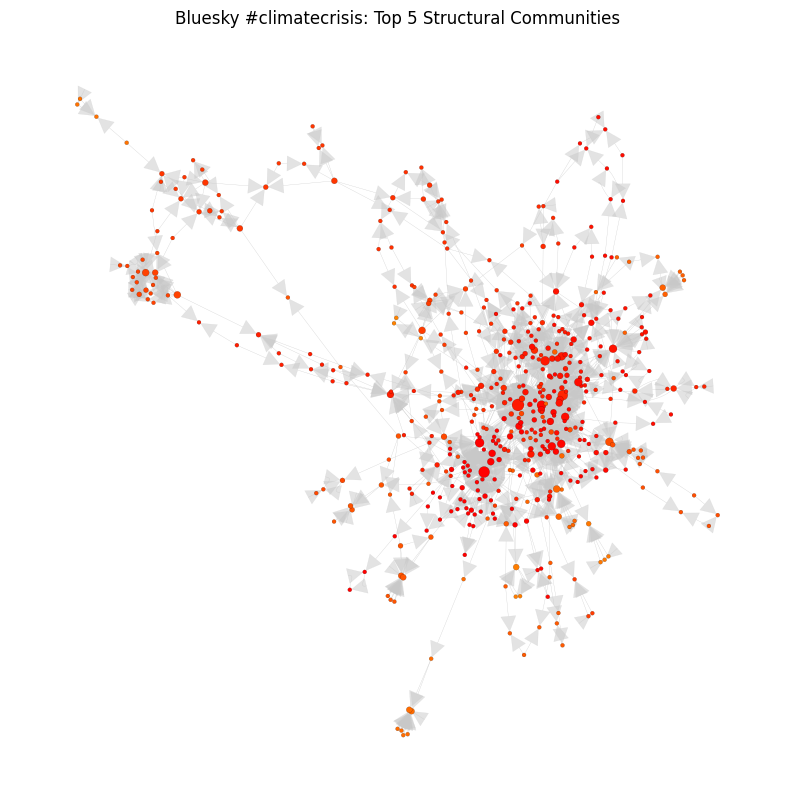

In [16]:
prepare_and_visualize(g_final, part)

In [ ]:
print("test")